# Retention adhoc

Analysis of encounter data from `abridge-client-prod.dbt_prod.tblEncounter`

## Setup


In [139]:
# Import libraries
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta


# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [140]:
# Initialize BigQuery client
client = bigquery.Client(project='abridge-client-prod')
print(f"Connected to project: {client.project}")


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connected to project: abridge-client-prod


## Data Exploration


In [ ]:
query0= 'select * from dbt_mchen.retention_temp'
bq_df = client.query(query0).to_dataframe()

# FIX: Convert the BigFrames DataFrame to a standard in-memory pandas DataFrame (pd.DataFrame)
# This resolves persistent type incompatibility issues with pd.get_dummies and BigFrames types.
try:
    # Use to_pandas if bq_df is a BigFrames DataFrame
    df = bq_df.to_pandas()
except AttributeError:
    # If bq_df is already a pandas DataFrame (e.g., if loaded from CSV for testing), proceed.
    df = bq_df.copy()

In [ ]:
bq_df[bq_df['encounter_surface'] == 'copy-paste']['tot_notes_28d'].describe()

count      17582.0
mean     62.067853
std       69.19677
min            1.0
25%            9.0
50%           37.0
75%           94.0
max          768.0
Name: tot_notes_28d, dtype: Float64

In [ ]:
bq_df['tot_notes_28d'].describe()

count      66819.0
mean      61.95395
std      71.867051
min            0.0
25%            6.0
50%           34.0
75%           96.0
max          768.0
Name: tot_notes_28d, dtype: Float64

In [ ]:
df.shape

(66819, 25)

In [ ]:
bq_df.head()

,unique_id,num_days_recod_first_7d,tot_recod_min_first_7d,tot_notes_first_7d,avg_record_per_note_7d,avg_recod_min_28d,tot_recod_min_28d,tot_notes_28d,avg_record_min_per_note_28d,tot_inside_notes_28d,...,nurse,roles,care_setting,encounter_surface,os_names_used,num_recordings_started,num_recordings_completed,num_recordings_longer_than_10_seconds,num_recordings_sent_to_epic,is_mru
0,abridge_m6Diswe4OIUimbGlB4OY5RNZIfl1_generic,0,0.0,0,NaN,0.0,0.0,0,NaN,0,...,False,clinician,None,copy-paste,None,3,2,2,0,False
1,fhir_ser_etmx1wL0lF9rqrmclLfT51w3,0,0.0,0,NaN,0.0,0.0,0,NaN,0,...,False,clinician,outpatient,copy-paste,ios,11,10,10,7,True
2,kp_nuid_G639736,0,0.0,0,NaN,0.0,0.0,0,NaN,0,...,False,clinician,None,copy-paste,ios,261,229,220,0,False
3,abridge_p2DUPjcSxUehVbSc0dKm3ICpd0D2,0,0.0,0,NaN,0.0,0.0,0,NaN,0,...,False,clinician,None,copy-paste,None,31,30,31,0,False
4,kp_nuid_A453121,0,0.0,0,NaN,0.0,0.0,0,NaN,0,...,False,clinician,outpatient,copy-paste,ios,3,2,0,0,False


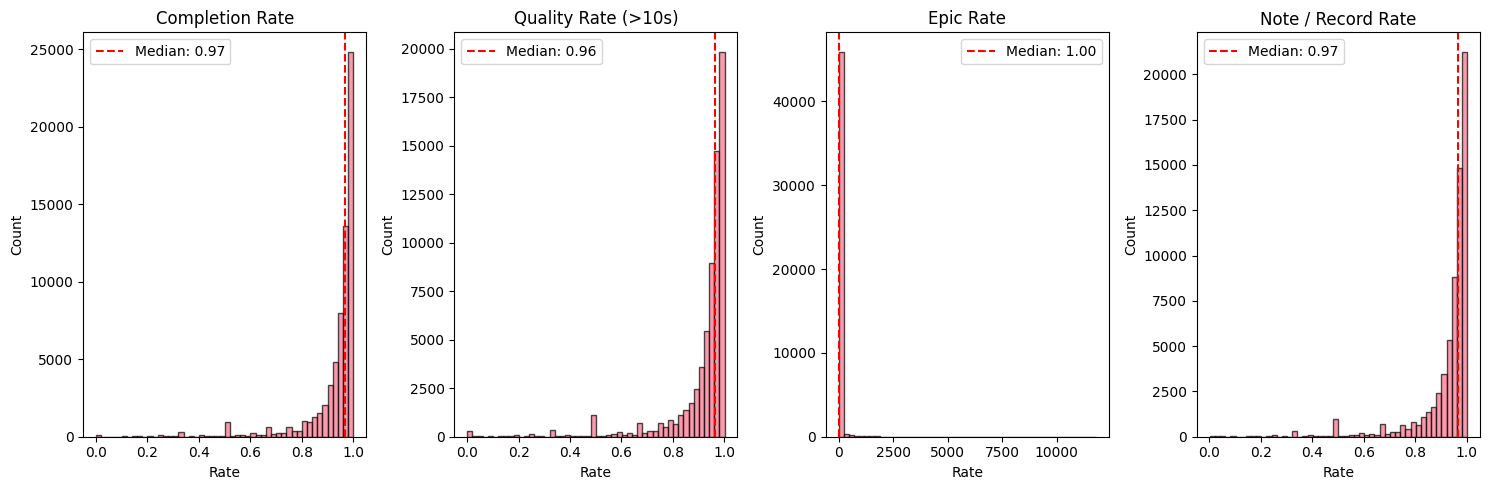

=== RATIO SUMMARY STATS ===
                  Count Average     P5    P10    P25    P50     P90
completion_rate   66838   92.8%  66.7%  82.8%  92.6%  96.9%  100.0%
quality_rate      66838   91.7%  66.1%  80.0%  91.6%  96.4%   99.8%
note_record_rate  66838   92.6%  66.7%  82.3%  92.3%  96.7%  100.0%


In [ ]:
# Compute ratios for each user
ratios = bq_df.copy()

# Calculate ratios (handle division by zero)
ratios['note_record_rate'] = ratios['num_notes_generated'] / ratios['num_recordings_started'].replace(0, np.nan)
ratios['completion_rate'] = ratios['num_recordings_completed'] / ratios['num_recordings_started'].replace(0, np.nan)
ratios['quality_rate'] = ratios['num_recordings_longer_than_10_seconds'] / ratios['num_recordings_started'].replace(0, np.nan)
ratios['epic_rate'] = ratios['num_recordings_completed'] / ratios['num_recordings_sent_to_epic'].replace(0, np.nan)

# Distribution plots
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, (col, title) in enumerate([
    ('completion_rate', 'Completion Rate'),
    ('quality_rate', 'Quality Rate (>10s)'), 
    ('epic_rate', 'Epic Rate'),
    ('note_record_rate', 'Note / Record Rate')
]):
    axes[i].hist(ratios[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(title)
    axes[i].set_xlabel('Rate')
    axes[i].set_ylabel('Count')
    axes[i].axvline(ratios[col].median(), color='red', linestyle='--', 
        label=f'Median: {ratios[col].median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Alternative with pandas styling
print("=== RATIO SUMMARY STATS ===")

summary_stats = {}
# epic_rate
columns_to_analyze = ['completion_rate', 'quality_rate', 'note_record_rate']

for col in columns_to_analyze:
    if col in ratios.columns:
        col_data = ratios[col].dropna()
        summary_stats[col] = {
            'Count': len(col_data),
            'Average': col_data.mean(),
            'P5': col_data.quantile(0.05),
            'P10': col_data.quantile(0.10),
            'P25': col_data.quantile(0.25),
            'P50': col_data.quantile(0.50),
            'P90': col_data.quantile(0.90)
        }

summary_df = pd.DataFrame(summary_stats).T

# Format for display
display_df = summary_df.copy()
display_df['Count'] = display_df['Count'].astype(int)

# Convert to percentages and format
percentage_cols = ['Average', 'P5', 'P10', 'P25', 'P50', 'P90']
for col in percentage_cols:
    display_df[col] = (display_df[col] * 100).round(1).astype(str) + '%'

print(display_df.to_string())

In [ ]:
# Updated aggregate function with error handling
def compute_aggregate_ratios(df, group_cols):
    """Compute aggregate ratios by grouping columns"""
    
    # Check if all group columns exist
    missing_cols = [col for col in group_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns {missing_cols}")
        group_cols = [col for col in group_cols if col in df.columns]
        if not group_cols:
            return None
    
    agg_data = df.groupby(group_cols).agg({
        'num_notes_generated': 'sum',
        'num_recordings_completed': 'sum',
        'num_recordings_started': 'sum', 
        'num_recordings_longer_than_10_seconds': 'sum',
        'num_recordings_sent_to_epic': 'sum'
    }).reset_index()
    
    # Calculate aggregate ratios

    agg_data['completion_rate'] = agg_data['num_recordings_completed'] / agg_data['num_recordings_started']
    agg_data['quality_rate'] = agg_data['num_recordings_longer_than_10_seconds'] / agg_data['num_recordings_started']  
    agg_data['epic_rate'] = agg_data['num_recordings_completed'] / agg_data['num_recordings_sent_to_epic']
    agg_data['note_record_rate'] = agg_data['num_notes_generated'] / agg_data['num_recordings_started']
    return agg_data[group_cols + ['completion_rate', 'quality_rate', 'epic_rate', 'note_record_rate']].round(3)

# Compute by available dimensions
encounter_ratios = compute_aggregate_ratios(bq_df, ['encounter_surface'])
care_ratios = compute_aggregate_ratios(bq_df, ['care_setting'])
os_ratios = compute_aggregate_ratios(bq_df, ['os_names_used'])

print("=== BY ENCOUNTER SURFACE ===")
print(encounter_ratios)

print("\n=== BY CARE SETTING ===") 
print(care_ratios)

print("\n=== BY OS NAMES USED ===")
print(os_ratios)

=== BY ENCOUNTER SURFACE ===
   encounter_surface  completion_rate  quality_rate  epic_rate  \
0         copy-paste            0.969         0.963      2.435   
1             inside            0.959         0.959      1.106   
2         integrated            0.985         0.982        inf   
3  integrated-athena            0.986         0.971        inf   

   note_record_rate  
0             0.965  
1             0.961  
2             0.982  
3             0.972  

=== BY CARE SETTING ===
          care_setting  completion_rate  quality_rate  epic_rate  \
0            emergency            0.961          0.96      1.598   
1  hospital_outpatient            0.965         0.965      2.017   
2            inpatient            0.957         0.957      1.321   
3              nursing            0.723         0.843        inf   
4           outpatient            0.964         0.962      1.518   

   note_record_rate  
0             0.962  
1             0.966  
2             0.959  
3       

In [153]:
def analyze_retention_no_vs_one_note(df, group_column, notes_column='tot_notes_28d'):
    """
    Analyze retention rate comparing 0 notes vs exactly 1 note by categorical variable
    """
    
    results = []
    
    print(f"=== RETENTION SUMMARY: 0 Notes vs 1 Note BY {group_column.upper().replace('_', ' ')} ===")
    
    for category in df[group_column].unique():
        if pd.isna(category):
            continue
            
        category_data = df[df[group_column] == category]
        
        # Users with 0 notes
        no_notes = category_data[category_data[notes_column] == 0]
        no_notes_retention = no_notes['is_mru'].mean() * 100 if len(no_notes) > 0 else 0
        
        # Users with exactly 1 note  
        one_note = category_data[category_data[notes_column] == 1]
        one_note_retention = one_note['is_mru'].mean() * 100 if len(one_note) > 0 else 0
        
        difference = one_note_retention - no_notes_retention
        
        # Store results
        results.append({
            'Category': category,
            'Group': group_column,
            'No_Notes_Count': len(no_notes),
            'One_Note_Count': len(one_note),
            'No_Notes_Retention': no_notes_retention,
            'One_Note_Retention': one_note_retention,
            'Difference': difference
        })
        
        print(f"\n{category}:")
        print(f"  0 notes (n={len(no_notes):,}):  {no_notes_retention:.1f}% retention")
        print(f"  1 note (n={len(one_note):,}):   {one_note_retention:.1f}% retention")
    
    return pd.DataFrame(results)

# Usage:
encounter_results = analyze_retention_no_vs_one_note(bq_df, 'encounter_surface')
care_results = analyze_retention_no_vs_one_note(bq_df, 'care_setting')

# Combine results
all_results = pd.concat([encounter_results, care_results], ignore_index=True)
print("\n=== COMBINED RESULTS: 0 vs 1 Note ===")
all_results

=== RETENTION SUMMARY: 0 Notes vs 1 Note BY ENCOUNTER SURFACE ===

integrated-athena:
  0 notes (n=1):  0.0% retention
  1 note (n=0):   0.0% retention

copy-paste:
  0 notes (n=4,076):  20.7% retention
  1 note (n=1,186):   87.4% retention

inside:
  0 notes (n=3,815):  22.0% retention
  1 note (n=1,009):   85.9% retention

integrated:
  0 notes (n=473):  17.8% retention
  1 note (n=153):   83.7% retention
=== RETENTION SUMMARY: 0 Notes vs 1 Note BY CARE SETTING ===

outpatient:
  0 notes (n=4,964):  22.8% retention
  1 note (n=1,429):   87.0% retention

inpatient:
  0 notes (n=240):  30.0% retention
  1 note (n=85):   90.6% retention

emergency:
  0 notes (n=479):  26.5% retention
  1 note (n=132):   82.6% retention

nursing:
  0 notes (n=117):  22.2% retention
  1 note (n=37):   89.2% retention

hospital_outpatient:
  0 notes (n=11):  9.1% retention
  1 note (n=2):   100.0% retention

=== COMBINED RESULTS: 0 vs 1 Note ===


,Category,Group,No_Notes_Count,One_Note_Count,No_Notes_Retention,One_Note_Retention,Difference
0,integrated-athena,encounter_surface,1,0,0.000000,0.000000,0.000000
1,copy-paste,encounter_surface,4076,1186,20.706575,87.352445,66.645870
2,inside,encounter_surface,3815,1009,22.044561,85.926660,63.882099
3,integrated,encounter_surface,473,153,17.758985,83.660131,65.901146
4,outpatient,care_setting,4964,1429,22.824335,86.983905,64.159570
5,inpatient,care_setting,240,85,30.000000,90.588235,60.588235
6,emergency,care_setting,479,132,26.513570,82.575758,56.062188
7,nursing,care_setting,117,37,22.222222,89.189189,66.966967
8,hospital_outpatient,care_setting,11,2,9.090909,100.000000,90.909091


--- MRU Baseline: 89.11% of users are Monthly Recording Users (is_mru=True) ---

--- MRU Baselines by Category ---

MRU Rate by care_setting:
care_setting
hospital_outpatient    100.00
outpatient              99.18
emergency               98.07
inpatient               97.18
nursing                 92.81
None                    71.13
Name: is_mru, dtype: float64

MRU Rate by encounter_surface:
encounter_surface
integrated-athena    100.00
integrated            99.15
inside                99.03
copy-paste            98.32
None                  21.15
Name: is_mru, dtype: float64

MRU Rate by roles:
roles
admin              100.00
reporting-admin    100.00
qa                  96.67
clinician           89.24
nurse               68.79
Name: is_mru, dtype: float64

MRU Rate by specialty:
specialty
Wound Care|Physical Medicine and Rehabilitation                  100.0
Resident                                                         100.0
Neurology|Neurological Surgery                          

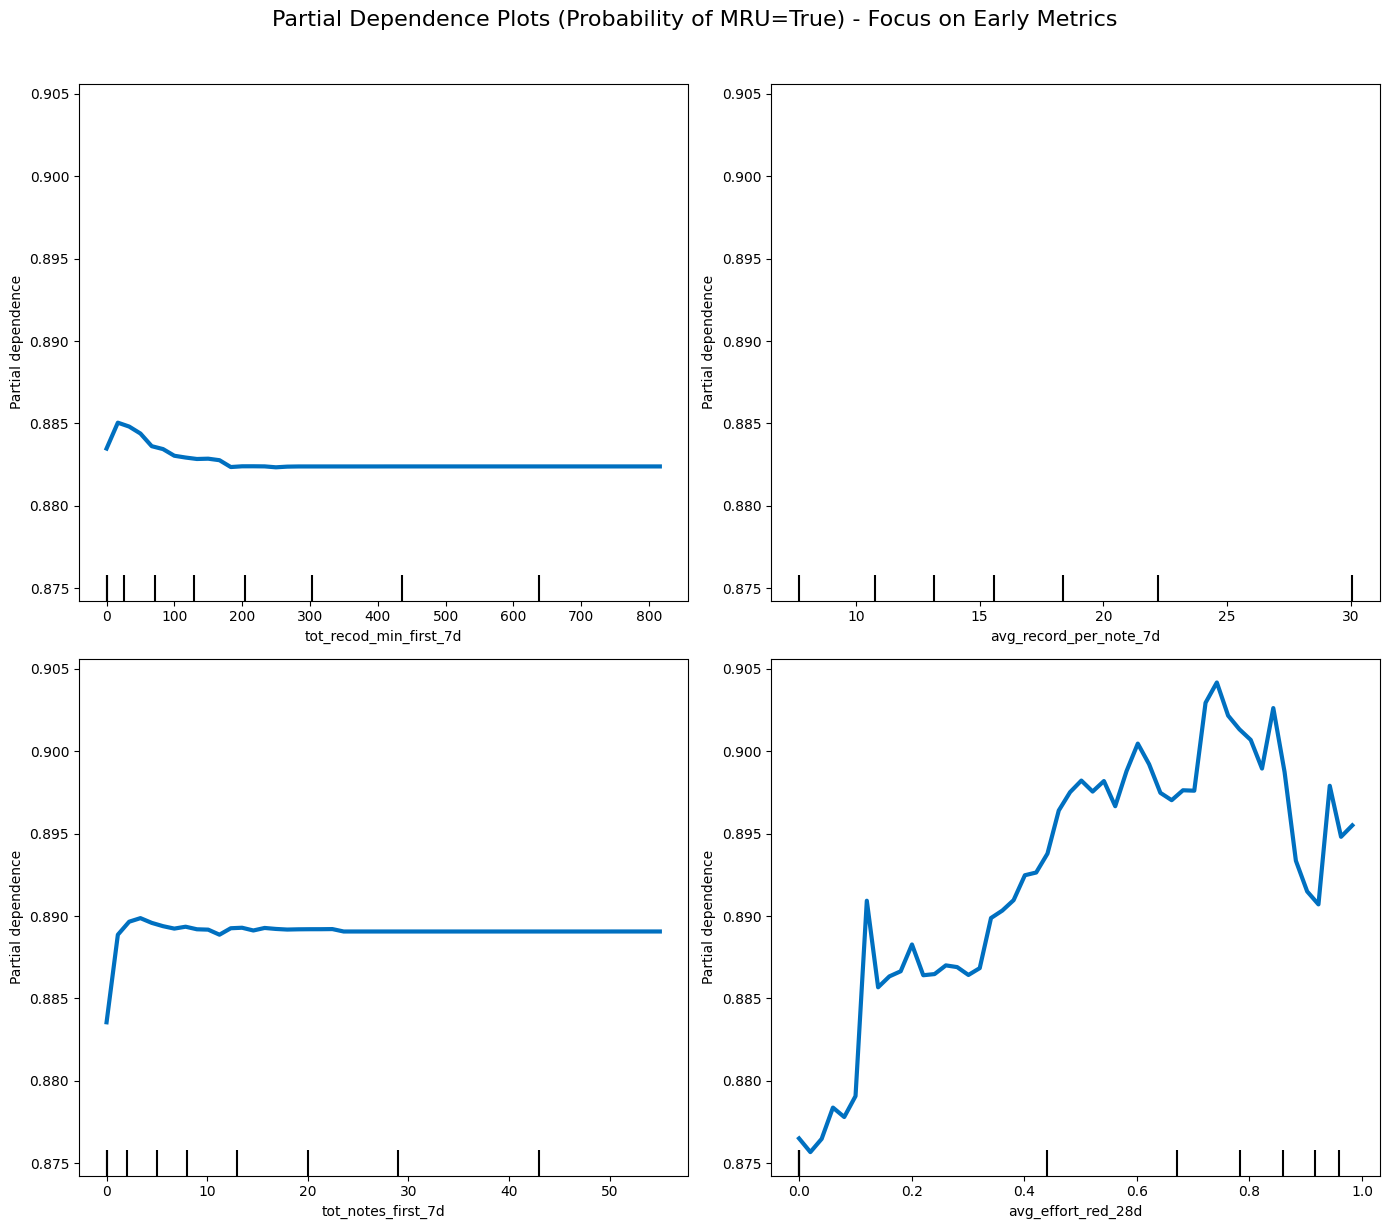

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance, partial_dependence

from decimal import Decimal

# --- NOTE: It is assumed bq_df is loaded from BigQuery using bf.read_gbq(query0) ---

# FIX: Convert the BigFrames DataFrame to a standard in-memory pandas DataFrame (pd.DataFrame)
# This resolves persistent type incompatibility issues with pd.get_dummies and BigFrames types.
try:
    # Use to_pandas if bq_df is a BigFrames DataFrame
    df = bq_df.to_pandas()
except AttributeError:
    # If bq_df is already a pandas DataFrame (e.g., if loaded from CSV for testing), proceed.
    # Note: If running this in a vanilla Python environment, replace 'bq_df' with the actual
    # variable holding your loaded CSV data.
    # df = pd.read_csv("bquxjob_3cb23066_19a405435e2.csv") 
    df = bq_df.copy()

# Drop unique_id
df = df.drop('unique_id', axis=1)

# Convert boolean columns to integer (0 or 1)
bool_cols = ['inside_user', 'nurse', 'is_mru']
for col in bool_cols:
    df[col] = df[col].astype(int)

# --- Data Cleaning and Imputation ---
# 1. Impute 'avg_effort_red_28d' with 0 (as null likely means no value recorded/not used)
df['avg_effort_red_28d'] = df['avg_effort_red_28d'].fillna(0)

# 2. Impute categorical columns (now expected to be simple STRINGs due to SQL fix)
# Fill NULLs from empty arrays/NaNs with 'None' category for one-hot encoding.
categorical_impute_cols = ['care_setting', 'encounter_surface', 'roles', 'specialty']
for col in categorical_impute_cols:
    df[col] = df[col].fillna('None')
    
# --- FIX FOR DECIMAL TYPE ERROR (Final Insurance Step) ---
# Identify and convert columns containing decimal.Decimal objects to float64.
# This prevents TypeErrors in scikit-learn's internal percentile calculations.
for col in df.columns:
    # Check if the column is numeric and contains the Decimal type
    if pd.api.types.is_numeric_dtype(df[col]) and len(df[col]) > 0:
        # Check if any non-null element is a Decimal (safer than relying on dtype alone)
        first_non_null = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
        
        if isinstance(first_non_null, Decimal):
            df[col] = df[col].astype(float)
        
# --- Baseline & Grouped Baselines (before One-Hot Encoding) ---
mru_baseline = df['is_mru'].mean() * 100
print(f"--- MRU Baseline: {mru_baseline:.2f}% of users are Monthly Recording Users (is_mru=True) ---\n")

# --- Grouped MRU Baselines ---
grouped_baseline_cols = ['care_setting', 'encounter_surface', 'roles', 'specialty', 'org'] 

print("--- MRU Baselines by Category ---\n")
for col in grouped_baseline_cols:
    # Calculate the mean of is_mru (MRU rate) grouped by the category
    grouped_rates = df.groupby(col)['is_mru'].mean().sort_values(ascending=False) * 100
    print(f"MRU Rate by {col}:\n{grouped_rates.round(2)}\n")

# --- Prepare Data for Modeling ---
# Apply one-hot encoding
categorical_cols = ['care_setting', 'encounter_surface', 'specialty', 'org', 'roles']

# FIX: Explicitly convert categorical columns to 'str' dtype to ensure pandas
for col in categorical_cols:
    df[col] = df[col].astype(str)

df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# --- Data Split and Modeling ---
X = df_processed.drop('is_mru', axis=1)
y = df_processed['is_mru']

# Final type coercion for the feature matrix X before passing to scikit-learn
# This guarantees that the matrix is purely float/int and avoids the Decimal error.
X = X.apply(pd.to_numeric, errors='coerce').astype('float64')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Model Training ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# --- Model Evaluation (for context) ---
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"--- Model Evaluation (Test Set) ---\n")
print(f"AUC: {roc_auc:.4f}")
print(report)

# --- FEATURE IMPORTANCE (Permutation Importance - Robust to Dimensionality) ---
# Calculate PFI on the test set using ROC AUC score
pfi_results = permutation_importance(
    rf_model, X_test, y_test,
    scoring='roc_auc', 
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Organize PFI results
sorted_idx = pfi_results.importances_mean.argsort()[::-1]
pfi_importances = pd.Series(
    pfi_results.importances_mean[sorted_idx],
    index=X.columns[sorted_idx]
)
top_10_pfi = pfi_importances.head(10)

print("--- Permutation Feature Importances (PFI) - Top 10 (AUC-based) ---\n")
print(top_10_pfi)

# --- Partial Dependence Plot (PDP) Generation ---

# Select the top 4 LEAST LEAKY, most impactful numerical features for visualization
# Focus on Day 7 metrics for a cleaner, earlier signal.
top_pdp_features = [
    'tot_recod_min_first_7d',
    'avg_record_per_note_7d',
    'tot_notes_first_7d',
    'avg_effort_red_28d' # Retaining this as the value metric, imputed at 0.
]

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Generate and plot PDPs
PartialDependenceDisplay.from_estimator(
    rf_model,
    X,
    features=top_pdp_features,
    ax=axes,
    feature_names=X.columns,
    target=1, # Probability of is_mru=True
    line_kw={'color': '#0070c0', 'linewidth': 3},
    kind='average',
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots (Probability of MRU=True) - Focus on Early Metrics', fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig('pdp_summary_chart.png')
# plt.close(fig)

print("\nPartial Dependence Plot summary chart saved as pdp_summary_chart.png")


In [59]:

# get the dataframe for pdp
pdp_raw = partial_dependence(
        rf_model, 
        X, 
        features=['tot_notes_first_7d'], 
        kind='average',
        grid_resolution=50,
        response_method='predict_proba'
    )
    
# Extract grid values (X) and average dependence (Y) for the MRU class (target=1)
avg_dep = pdp_raw.average[0] 
    
grid_values = pdp_raw.grid_values[0]
    
    # Print the full list of X and Y values
    # print(f"\n--- Full PDP Coordinates for {feature_name} ---")
pdp_df = pd.DataFrame({
        'X_Value': grid_values,
        'MRU_Probability': avg_dep
})
# print(pdp_df.to_string(index=False, float_format="%.4f"))

In [60]:
# --- Model Evaluation (for context) ---
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"--- Model Evaluation (Test Set) ---\n")
print(f"AUC: {roc_auc:.4f}")
print(report)

--- Model Evaluation (Test Set) ---

AUC: 0.9858
              precision    recall  f1-score   support

           0       0.80      0.90      0.85      1455
           1       0.99      0.97      0.98     11909

    accuracy                           0.96     13364
   macro avg       0.89      0.94      0.91     13364
weighted avg       0.97      0.96      0.97     13364



In [79]:
def analyze_pdp_by_dimension_subplots(model, X, df_original, feature_name='tot_notes_first_7d', 
                                     dimension='specialty', grid_resolution=50, min_samples=10,
                                     figsize=(15, 10), save_plot=True, x_limit=100):
    """
    Analyze PDP by dimension with subplot visualization only
    
    Parameters:
    - model: trained model
    - X: feature matrix
    - df_original: original dataframe with categorical columns
    - feature_name: feature to analyze for PDP
    - dimension: categorical column to group by
    - grid_resolution: number of grid points for PDP
    - min_samples: minimum samples required per category
    - figsize: figure size for plots
    - save_plot: whether to save plots
    - x_limit: maximum value for x-axis (None for no limit)
    
    Returns:
    - pdp_dataframe: Clean dataframe with X_Value, Y_Value, Category, Sample_Size
    - plot_figure: matplotlib figure object
    """
    
    print(f"=== Analyzing PDP for '{feature_name}' by '{dimension}' ===\n")
    
    # Generate the PDP data using existing function
    pdp_data, pdp_dict = create_pdp_by_category(
        model=model,
        X=X, 
        df_original=df_original,
        feature_name=feature_name,
        category_column=dimension,
        grid_resolution=grid_resolution,
        min_samples=min_samples
    )
    
    if pdp_data is None or len(pdp_data) == 0:
        print("No PDP data generated - check for errors above")
        return None, None
    
    # Create standardized output dataframe
    pdp_clean = pdp_data.rename(columns={
        'X_Value': 'X_Value',
        'MRU_Probability': 'Y_Value',
        dimension: 'Category'
    })[['X_Value', 'Y_Value', 'Category', 'Sample_Size']].copy()
    
    # Print summary
    categories = pdp_clean['Category'].unique()
    print(f"\n--- PDP Analysis Summary ---")
    print(f"Dimension: {dimension}")
    print(f"Feature: {feature_name}")
    print(f"Categories processed: {len(categories)}")
    print(f"Total data points: {len(pdp_clean)}")
    
    # Show sample sizes
    sample_sizes = pdp_clean.groupby('Category')['Sample_Size'].first().sort_values(ascending=False)
    print(f"\nSample sizes by {dimension}:")
    for cat, size in sample_sizes.items():
        print(f"  {cat}: {size:,} samples")
    
    # Create subplot visualization
    n_categories = len(categories)
    cols = min(3, n_categories)  # Max 3 columns
    rows = (n_categories + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    for i, category in enumerate(categories):
        cat_data = pdp_clean[pdp_clean['Category'] == category]
        sample_size = cat_data['Sample_Size'].iloc[0]
        
        axes[i].plot(cat_data['X_Value'], cat_data['Y_Value'], 
                    linewidth=2.5, marker='o', markersize=4, color='#2E86C1')
        axes[i].set_title(f'{category}\n({sample_size:,} samples)', fontsize=10, pad=10)
        axes[i].set_xlabel(feature_name)
        axes[i].set_ylabel('MRU Probability')
        axes[i].grid(True, alpha=0.3)
        
        # Limit x-axis
        if x_limit is not None:
            axes[i].set_xlim(0, x_limit)
        
    # Hide unused subplots
    for i in range(len(categories), len(axes)):
        axes[i].set_visible(False)
        
    plt.suptitle(f'Partial Dependence Plots by {dimension.title()}\nFeature: {feature_name}', 
                fontsize=14, y=0.98)
    plt.tight_layout()
    
    # Save plot if requested
    if save_plot:
        safe_feature = feature_name.replace('/', '_').replace(' ', '_')
        filename = f'pdp_{dimension}_{safe_feature}_subplots.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved: {filename}")
    
    plt.show()
    
    return pdp_clean, fig

# Simplified batch function for subplots only
def batch_pdp_subplots(model, X, df_original, feature_name, dimension, 
                      save_plots=True, x_limit=100, figsize=(15, 10)):
    """
    Generate PDP subplot analysis for multiple features in batch
    """
    all_dataframes = []
    all_figures = []
    
            
    pdp_df, fig = analyze_pdp_by_dimension_subplots(
            model, X, df_original,
            feature_name,
            dimension,
            save_plot=save_plots,
            x_limit=x_limit,
            figsize=figsize
    )
        
    return pdp_df, fig



=== Analyzing PDP for 'tot_notes_first_7d' by 'encounter_surface' ===

Generating PDP raw data for 'tot_notes_first_7d' by encounter_surface...
Found 5 unique categories in encounter_surface
Processing encounter_surface: None
  ✓ Completed None (8361 samples)
Processing encounter_surface: copy-paste
  ✓ Completed copy-paste (17582 samples)
Processing encounter_surface: inside
  ✓ Completed inside (32985 samples)
Processing encounter_surface: integrated
  ✓ Completed integrated (7872 samples)
Processing encounter_surface: integrated-athena
  ✓ Completed integrated-athena (19 samples)

--- PDP Analysis Summary ---
Dimension: encounter_surface
Feature: tot_notes_first_7d
Categories processed: 5
Total data points: 169

Sample sizes by encounter_surface:
  inside: 32,985 samples
  copy-paste: 17,582 samples
  None: 8,361 samples
  integrated: 7,872 samples
  integrated-athena: 19 samples

Plot saved: pdp_encounter_surface_tot_notes_first_7d_subplots.png


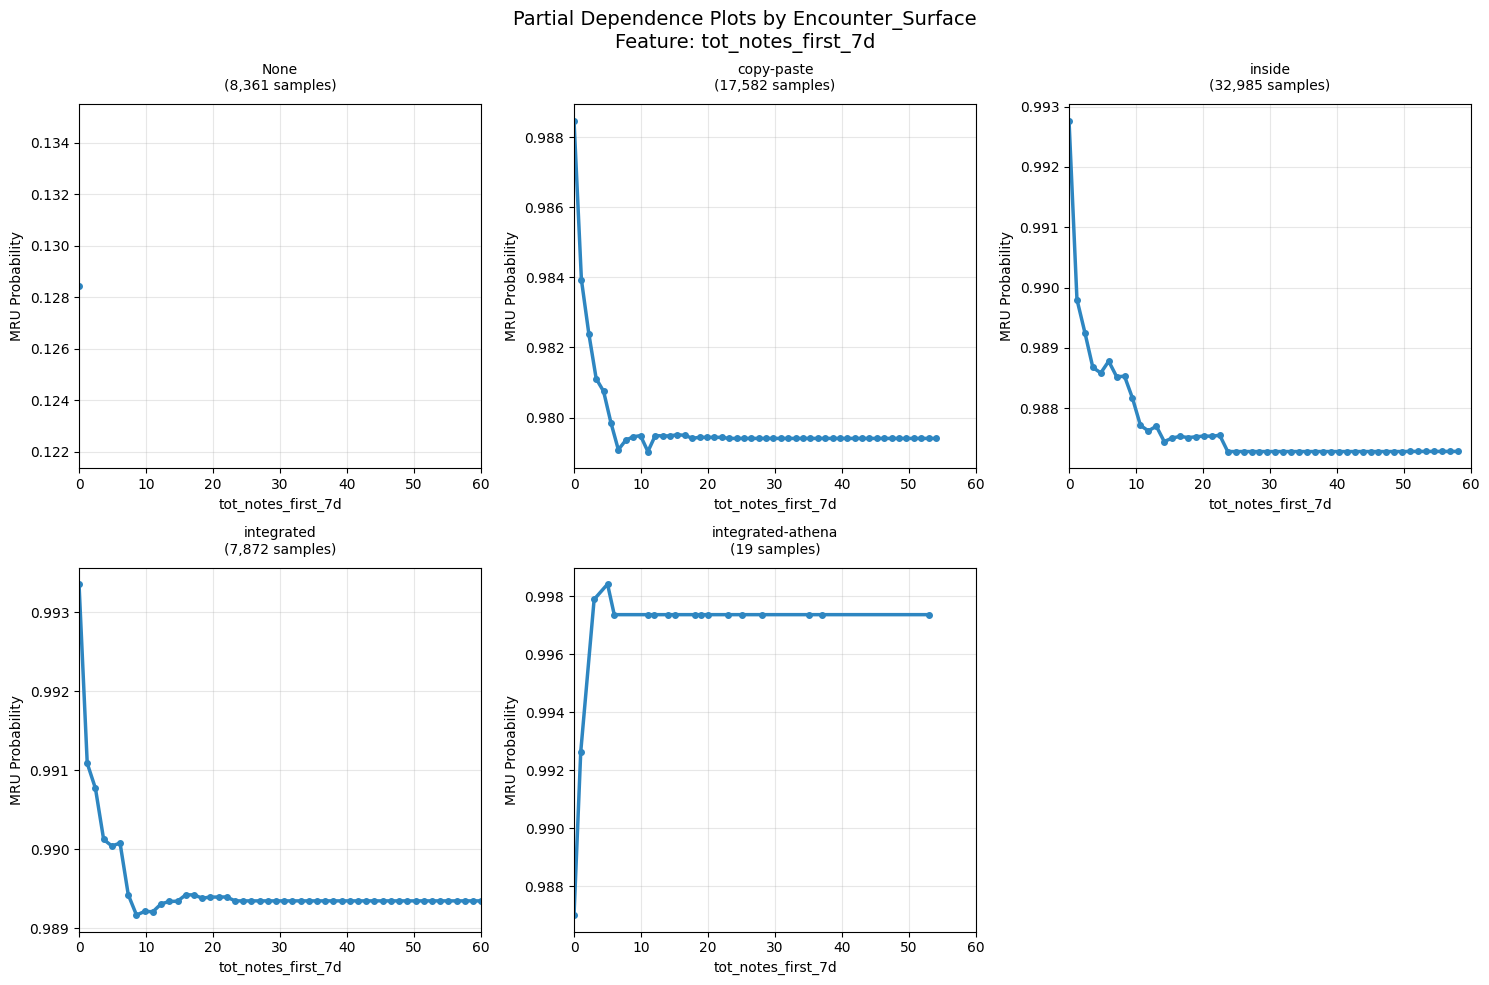

In [78]:
# Batch analysis for multiple features
batch_pdp_df, batch_figures = batch_pdp_subplots(
    rf_model, X, df,
    feature_name='tot_notes_first_7d',
    dimension='encounter_surface',
    x_limit=60
)

=== Analyzing PDP for 'tot_recod_min_first_7d' by 'encounter_surface' ===

Generating PDP raw data for 'tot_recod_min_first_7d' by encounter_surface...
Found 5 unique categories in encounter_surface
Processing encounter_surface: None
  ✓ Completed None (8361 samples)
Processing encounter_surface: copy-paste
  ✓ Completed copy-paste (17582 samples)
Processing encounter_surface: inside
  ✓ Completed inside (32985 samples)
Processing encounter_surface: integrated
  ✓ Completed integrated (7872 samples)
Processing encounter_surface: integrated-athena
  ✓ Completed integrated-athena (19 samples)

--- PDP Analysis Summary ---
Dimension: encounter_surface
Feature: tot_recod_min_first_7d
Categories processed: 5
Total data points: 170

Sample sizes by encounter_surface:
  inside: 32,985 samples
  copy-paste: 17,582 samples
  None: 8,361 samples
  integrated: 7,872 samples
  integrated-athena: 19 samples

Plot saved: pdp_encounter_surface_tot_recod_min_first_7d_subplots.png


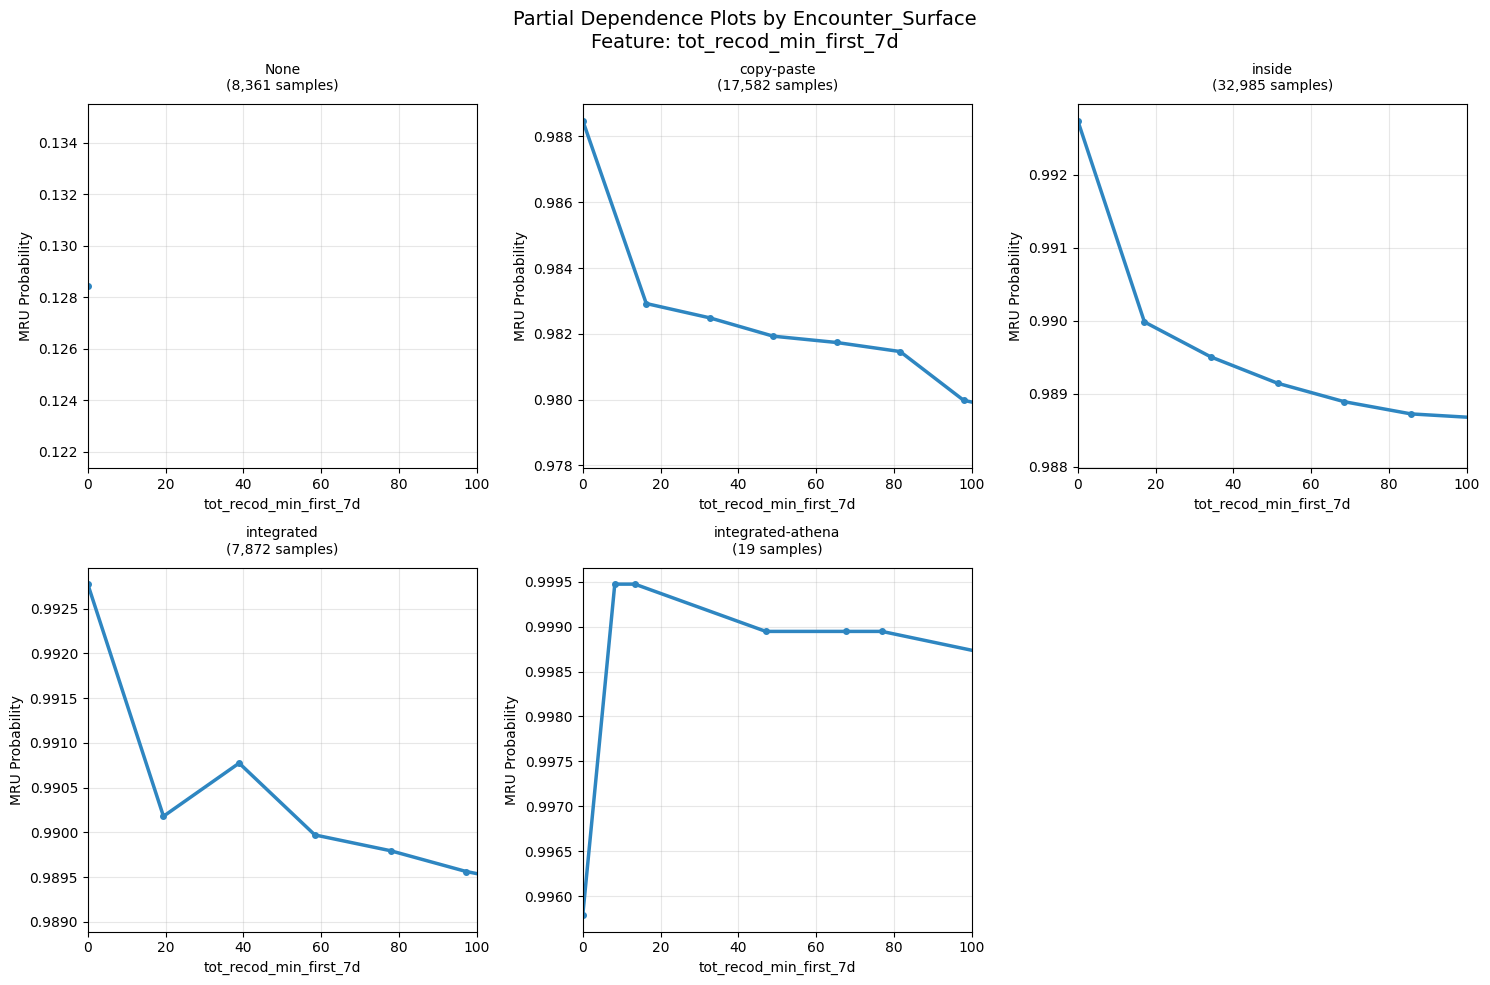

In [108]:
# Batch analysis for multiple features
batch_pdp_df, batch_figures = batch_pdp_subplots(
    rf_model, X, df,
    feature_name='tot_recod_min_first_7d',
    dimension='encounter_surface',
    x_limit=100
)

=== Analyzing PDP for 'tot_notes_28d' by 'encounter_surface' ===

Generating PDP raw data for 'tot_notes_28d' by encounter_surface...
Found 5 unique categories in encounter_surface
Processing encounter_surface: None
  ✓ Completed None (8361 samples)
Processing encounter_surface: copy-paste
  ✓ Completed copy-paste (17582 samples)
Processing encounter_surface: inside
  ✓ Completed inside (32985 samples)
Processing encounter_surface: integrated
  ✓ Completed integrated (7872 samples)
Processing encounter_surface: integrated-athena
  ✓ Completed integrated-athena (19 samples)

--- PDP Analysis Summary ---
Dimension: encounter_surface
Feature: tot_notes_28d
Categories processed: 5
Total data points: 170

Sample sizes by encounter_surface:
  inside: 32,985 samples
  copy-paste: 17,582 samples
  None: 8,361 samples
  integrated: 7,872 samples
  integrated-athena: 19 samples

Plot saved: pdp_encounter_surface_tot_notes_28d_subplots.png


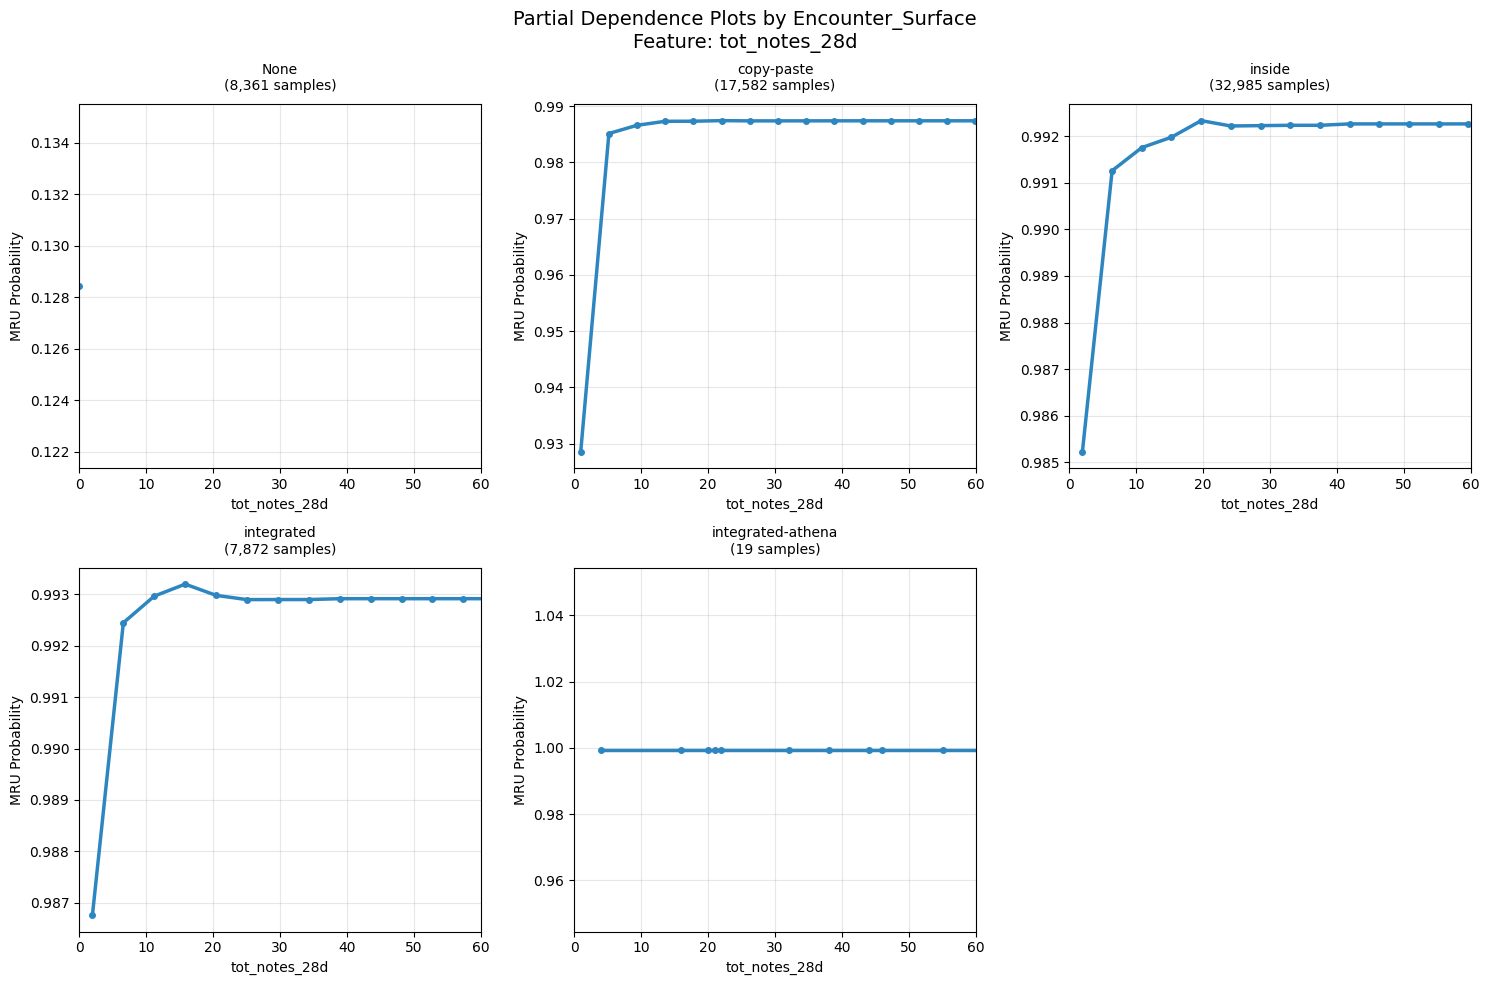

In [82]:
# Batch analysis for multiple features
pdf_tot_notes_28d, batch_figures = batch_pdp_subplots(
    rf_model, X, df,
    feature_name='tot_notes_28d',
    dimension='encounter_surface',
    x_limit=60
)

In [81]:
batch_pdp_df.head(10)

,X_Value,Y_Value,Category,Sample_Size
0,0.000000,0.128434,None,8361
1,1.000000,0.928612,copy-paste,17582
2,5.204082,0.985120,copy-paste,17582
3,9.408163,0.986584,copy-paste,17582
4,13.612245,0.987291,copy-paste,17582
5,17.816327,0.987302,copy-paste,17582
6,22.020408,0.987407,copy-paste,17582
7,26.224490,0.987364,copy-paste,17582
8,30.428571,0.987365,copy-paste,17582
9,34.632653,0.987368,copy-paste,17582


In [87]:
df[df['encounter_surface'] == 'copy-paste']['tot_notes_28d'].describe()

count      17582.0
mean     62.067853
std       69.19677
min            1.0
25%            9.0
50%           37.0
75%           94.0
max          768.0
Name: tot_notes_28d, dtype: Float64

=== Analyzing PDP for 'avg_record_min_per_note_28d' by 'encounter_surface' ===

Generating PDP raw data for 'avg_record_min_per_note_28d' by encounter_surface...
Found 5 unique categories in encounter_surface
Processing encounter_surface: None
  ✓ Completed None (8361 samples)
Processing encounter_surface: copy-paste
  ✓ Completed copy-paste (17582 samples)
Processing encounter_surface: inside
  ✓ Completed inside (32985 samples)
Processing encounter_surface: integrated
  ✓ Completed integrated (7872 samples)
Processing encounter_surface: integrated-athena
  ✓ Completed integrated-athena (19 samples)

--- PDP Analysis Summary ---
Dimension: encounter_surface
Feature: avg_record_min_per_note_28d
Categories processed: 5
Total data points: 170

Sample sizes by encounter_surface:
  inside: 32,985 samples
  copy-paste: 17,582 samples
  None: 8,361 samples
  integrated: 7,872 samples
  integrated-athena: 19 samples

Plot saved: pdp_encounter_surface_avg_record_min_per_note_28d_subplots.png


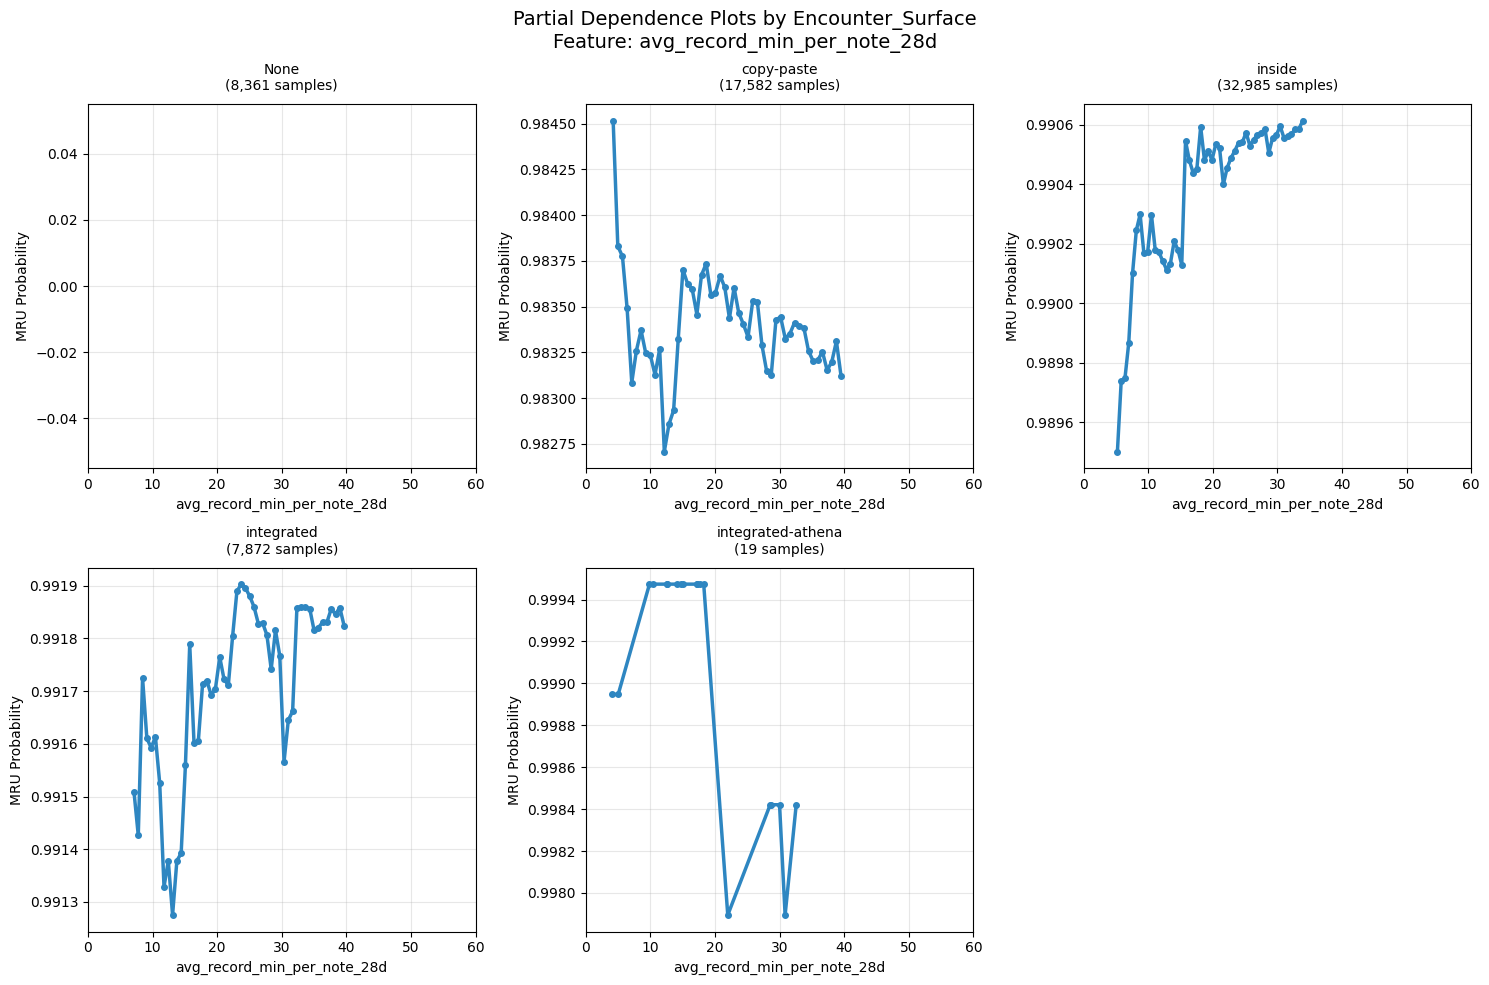

In [93]:
# Batch analysis for multiple features
pdf_tot_notes_28d, batch_figures = batch_pdp_subplots(
    rf_model, X, df,
    feature_name='avg_record_min_per_note_28d',
    dimension='encounter_surface',
    x_limit=60
)

=== Analyzing PDP for 'tot_recod_min_28d' by 'encounter_surface' ===

Generating PDP raw data for 'tot_recod_min_28d' by encounter_surface...
Found 5 unique categories in encounter_surface
Processing encounter_surface: None
  ✓ Completed None (8361 samples)
Processing encounter_surface: copy-paste
  ✓ Completed copy-paste (17582 samples)
Processing encounter_surface: inside
  ✓ Completed inside (32985 samples)
Processing encounter_surface: integrated
  ✓ Completed integrated (7872 samples)
Processing encounter_surface: integrated-athena
  ✓ Completed integrated-athena (19 samples)

--- PDP Analysis Summary ---
Dimension: encounter_surface
Feature: tot_recod_min_28d
Categories processed: 5
Total data points: 170

Sample sizes by encounter_surface:
  inside: 32,985 samples
  copy-paste: 17,582 samples
  None: 8,361 samples
  integrated: 7,872 samples
  integrated-athena: 19 samples

Plot saved: pdp_encounter_surface_tot_recod_min_28d_subplots.png


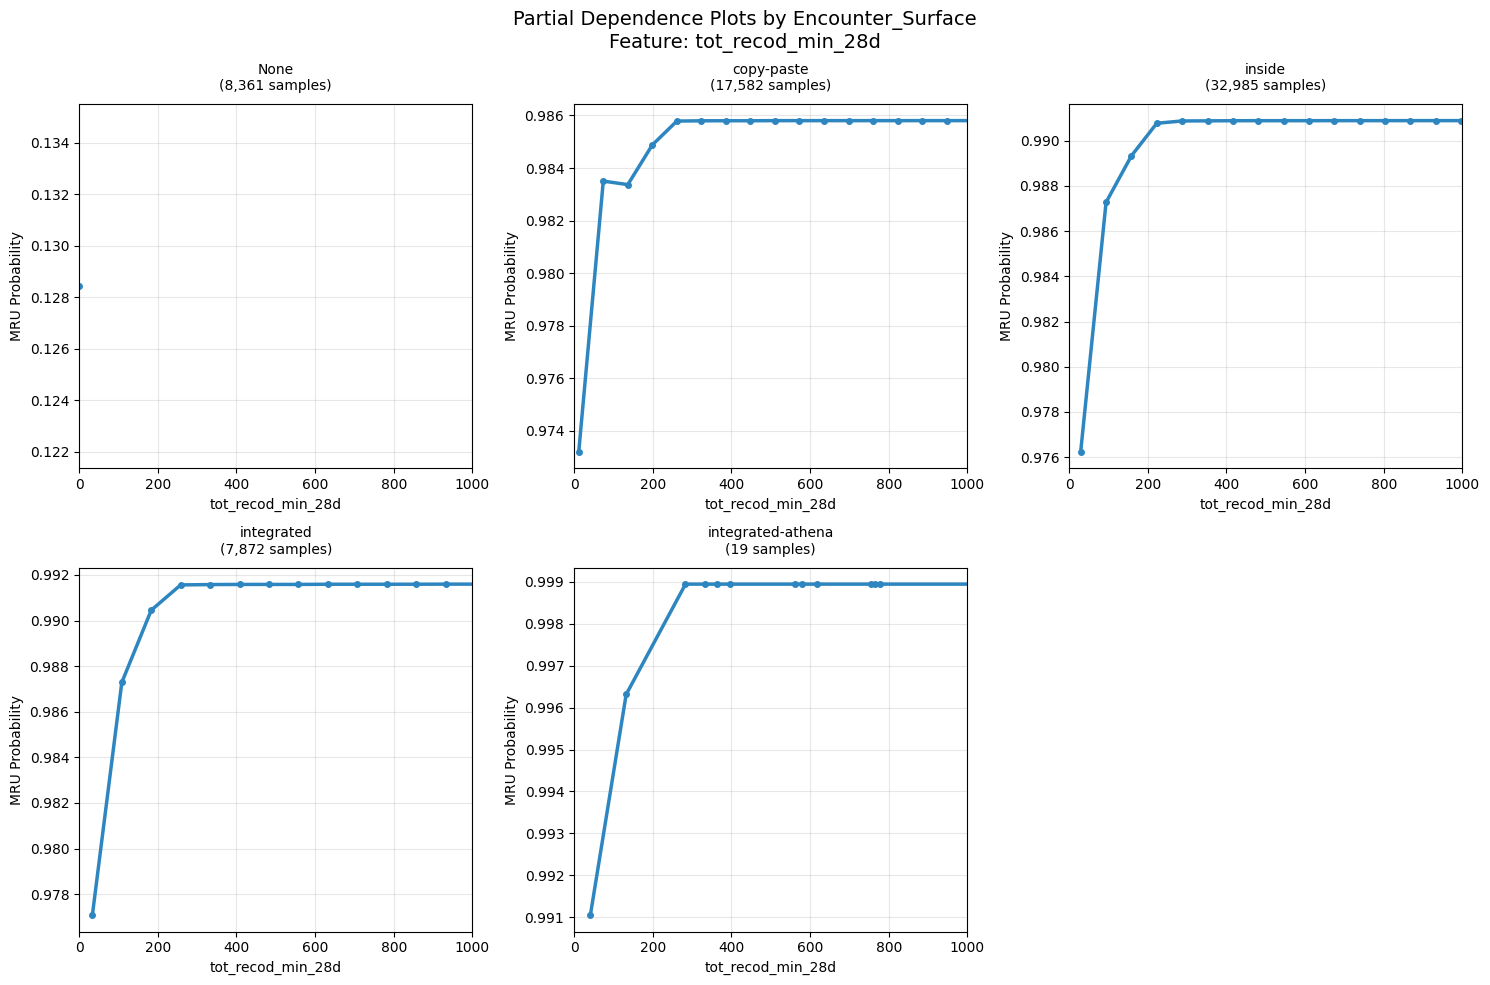

In [98]:
# Batch analysis for multiple features
pdf_tot_notes_28d, batch_figures = batch_pdp_subplots(
    rf_model, X, df,
    feature_name='tot_recod_min_28d',
    dimension='encounter_surface',
    x_limit=1000
)


=== Analyzing PDP for 'tot_notes_first_7d' by 'inside_user' ===

Generating PDP raw data for 'tot_notes_first_7d' by inside_user...
Found 2 unique categories in inside_user
Processing inside_user: 0
  ✓ Completed 0 (29927 samples)
Processing inside_user: 1
  ✓ Completed 1 (36892 samples)

--- PDP Analysis Summary ---
Dimension: inside_user
Feature: tot_notes_first_7d
Categories processed: 2
Total data points: 100

Sample sizes by inside_user:
  1: 36,892 samples
  0: 29,927 samples

Plot saved: pdp_inside_user_tot_notes_first_7d_subplots.png


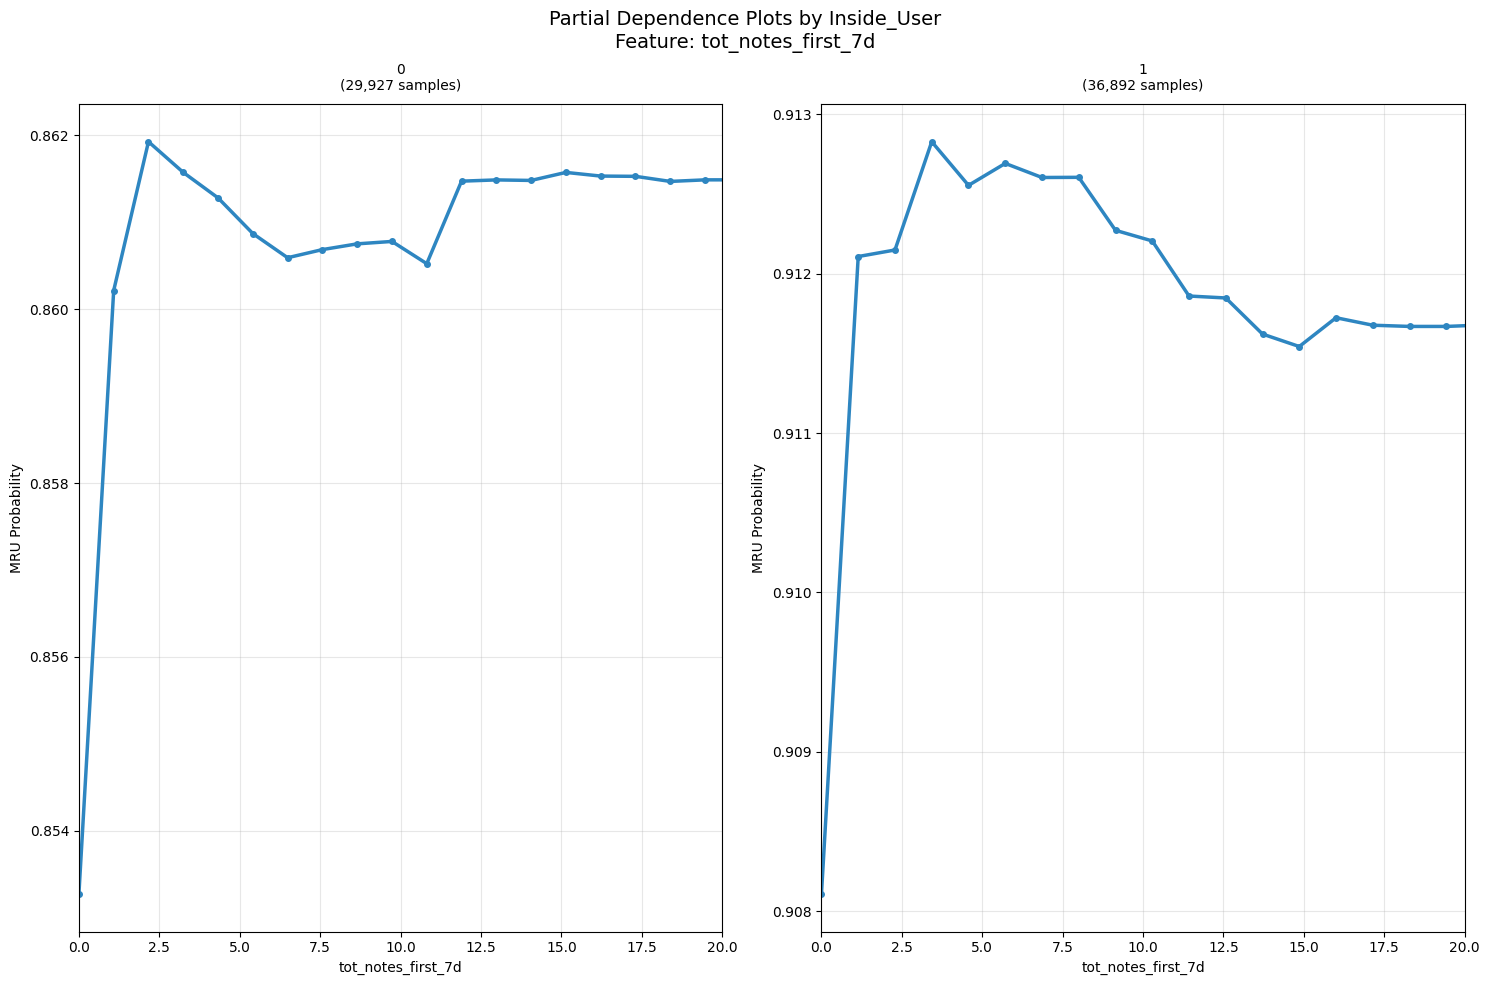

In [105]:
# Batch analysis for multiple features
pdf_tot_notes_28d, batch_figures = batch_pdp_subplots(
    rf_model, X, df,
    feature_name='tot_notes_first_7d',
    dimension='inside_user',
    x_limit=20
)


In [128]:
def generate_distribution_summary(df):
    """
    Generate detailed summary statistics for distributions
    """
    
    print("=== DISTRIBUTION SUMMARY STATISTICS ===\n")
    
    # Notes summary
    notes_summary = df.groupby('encounter_surface')['tot_notes_first_7d'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max',
        lambda x: x.quantile(0.25),  # Q1
        lambda x: x.quantile(0.75),  # Q3
        lambda x: x.quantile(0.90),  # 90th percentile
        lambda x: x.quantile(0.95)   # 95th percentile
    ]).round(2)
    
    notes_summary.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3', 'P90', 'P95']
    
    print("--- NOTES IN FIRST 7 DAYS ---")
    print(notes_summary)
    print()
    
    # Recording minutes summary
    minutes_summary = df.groupby('encounter_surface')['tot_recod_min_first_7d'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max',
        lambda x: x.quantile(0.25),  # Q1
        lambda x: x.quantile(0.75),  # Q3
        lambda x: x.quantile(0.90),  # 90th percentile
        lambda x: x.quantile(0.95)   # 95th percentile
    ]).round(2)
    
    minutes_summary.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3', 'P90', 'P95']
    
    print("--- RECORDING MINUTES IN FIRST 7 DAYS ---")
    print(minutes_summary)
    print()
    
    # Zero activity analysis
    zero_notes = df.groupby('encounter_surface')['tot_notes_first_7d'].apply(lambda x: (x == 0).sum())
    zero_minutes = df.groupby('encounter_surface')['tot_recod_min_first_7d'].apply(lambda x: (x == 0).sum())
    total_users = df.groupby('encounter_surface').size()
    
    zero_analysis = pd.DataFrame({
        'Total_Users': total_users,
        'Zero_Notes': zero_notes,
        'Zero_Notes_Pct': (zero_notes / total_users * 100).round(1),
        'Zero_Minutes': zero_minutes,
        'Zero_Minutes_Pct': (zero_minutes / total_users * 100).round(1)
    })
    
    print("--- ZERO ACTIVITY ANALYSIS ---")
    print(zero_analysis)
    
    return notes_summary, minutes_summary, zero_analysis

# Generate summary statistics
notes_stats, minutes_stats, zero_stats = generate_distribution_summary(df)

=== DISTRIBUTION SUMMARY STATISTICS ===

--- NOTES IN FIRST 7 DAYS ---
                   Count   Mean  Median    Std  Min  Max  Q1  Q3   P90   P95
encounter_surface                                                           
copy-paste         28606   14.4     7.0  18.56    0  204   0  22  40.0  53.0
inside             35074  16.78    10.0  19.57    0  189   1  26  45.0  57.0
integrated          3149  12.43     5.0  16.64    0  150   0  18  36.0  48.0
integrated-athena      9  10.56    11.0   8.82    0   25   5  12  23.4  24.2

--- RECORDING MINUTES IN FIRST 7 DAYS ---
                   Count    Mean  Median     Std  Min      Max     Q1      Q3  \
encounter_surface                                                               
copy-paste         28606  222.31  111.49  277.70  0.0  2143.20   0.00  346.88   
inside             35074  245.10  145.43  279.73  0.0  1935.60  17.77  382.85   
integrated          3149  205.16   99.42  264.88  0.0  1767.87   0.00  303.10   
integrated-athena  

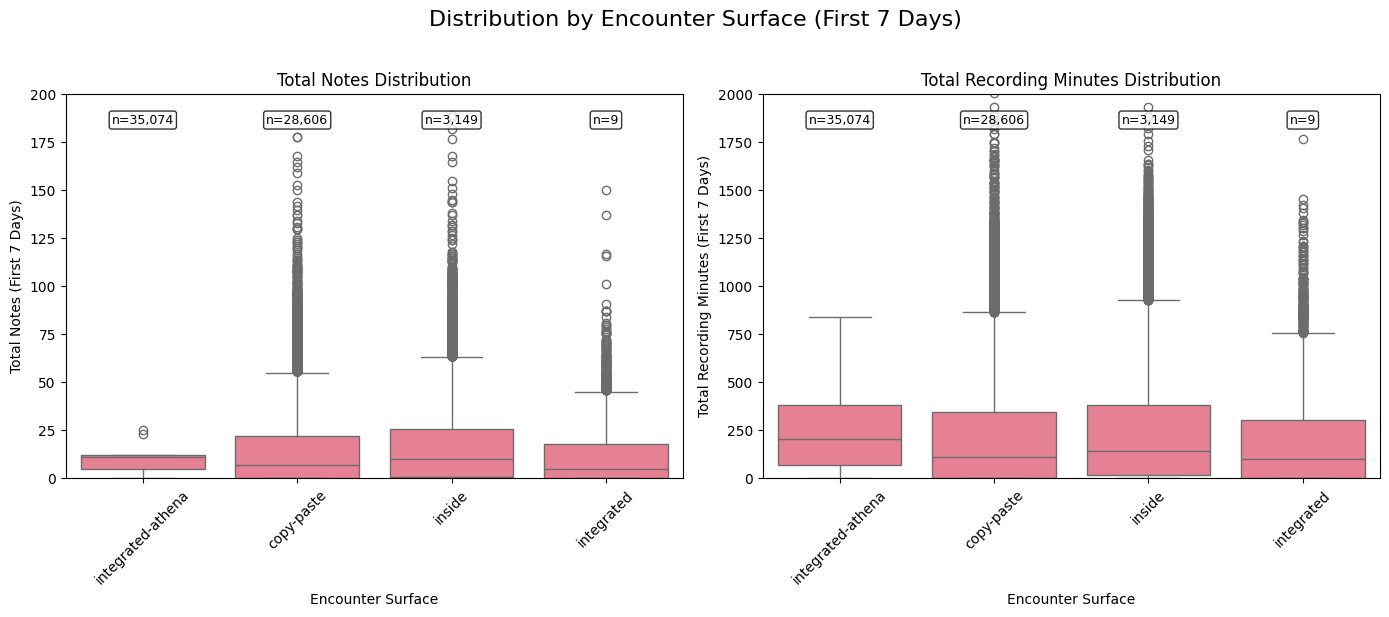

In [129]:
def create_boxplots_with_limits(df, notes_ylim=None, minutes_ylim=None, figsize=(14, 6)):
    """
    Create boxplots with optional y-axis limits
    """
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Distribution by Encounter Surface (First 7 Days)', fontsize=16, y=1.02)
    
    df_clean = df[df['encounter_surface'].notna()].copy()
    surface_counts = df_clean['encounter_surface'].value_counts()
    
    # Notes boxplot
    sns.boxplot(data=df_clean, x='encounter_surface', y='tot_notes_first_7d', ax=axes[0])
    axes[0].set_title('Total Notes Distribution')
    axes[0].set_ylabel('Total Notes (First 7 Days)')
    axes[0].set_xlabel('Encounter Surface')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Set y-limits if specified
    if notes_ylim:
        axes[0].set_ylim(notes_ylim)
    
    # Recording minutes boxplot
    sns.boxplot(data=df_clean, x='encounter_surface', y='tot_recod_min_first_7d', ax=axes[1])
    axes[1].set_title('Total Recording Minutes Distribution')
    axes[1].set_ylabel('Total Recording Minutes (First 7 Days)')
    axes[1].set_xlabel('Encounter Surface')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Set y-limits if specified
    if minutes_ylim:
        axes[1].set_ylim(minutes_ylim)
    
    # Add sample size annotations
    for i, surface in enumerate(surface_counts.index):
        n = surface_counts[surface]
        axes[0].text(i, axes[0].get_ylim()[1] * 0.95, f'n={n:,}', 
                    ha='center', va='top', fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
        axes[1].text(i, axes[1].get_ylim()[1] * 0.95, f'n={n:,}', 
                    ha='center', va='top', fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Example with y-axis limits to focus on main ranges
fig_limited = create_boxplots_with_limits(df, 
                                         notes_ylim=(0, 200),      # Focus on 0-25 notes
                                         minutes_ylim=(0, 2000))   # Focus on 0-100 minutes
